### Imports

In [24]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Directorio de trabajo actual:", os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

Directorio de trabajo actual: /content/red_neuronal


In [25]:
# Estructura de carpetas del proyecto local
base = "."
carpetas = ["data", "notebooks", "models", "images"]
for c in carpetas:
    os.makedirs(os.path.join(base, c), exist_ok=True)

print("Carpetas creadas:", os.listdir(base))

Carpetas creadas: ['.gitignore', '.git', 'models', 'notebooks', 'data', 'images', 'README.md']


DESCARGAR EL DATASET

In [26]:
import os

os.makedirs("data", exist_ok=True)

try:
    from google.colab import userdata
    token = userdata.get('KAGGLE_TOKEN')
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
        f.write(token)
    !chmod 600 ~/.kaggle/access_token
except ImportError:
    pass

!kaggle datasets download -d puneet6060/intel-image-classification -p data
!unzip -q -o data/intel-image-classification.zip -d data/intel_images

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [27]:
base_dir = "data/intel_images"
train_dir = os.path.join(base_dir, "seg_train", "seg_train")
test_dir  = os.path.join(base_dir, "seg_test", "seg_test")

print(os.listdir(train_dir))  # debería mostrar las 6 clases

['street', 'forest', 'buildings', 'sea', 'mountain', 'glacier']


EDA

Clases: ['buildings', 'forest', 'glacier']


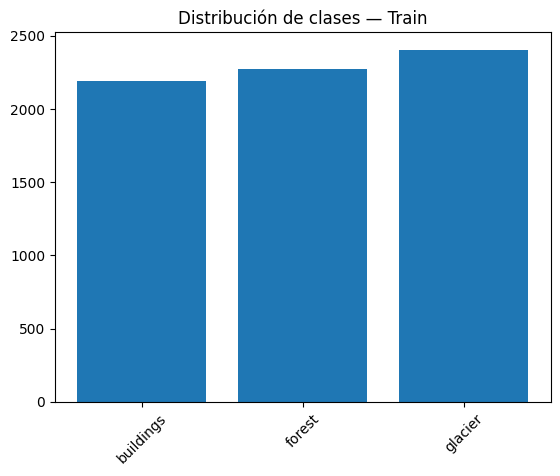

{'buildings': 2191, 'forest': 2271, 'glacier': 2404}


In [28]:
#clases = sorted(os.listdir(train_dir))
clases = ["buildings", "forest", "glacier"]
print("Clases:", clases)

# Conteo de imágenes por clase
conteo = {c: len(os.listdir(os.path.join(train_dir, c))) for c in clases}
plt.bar(conteo.keys(), conteo.values())
plt.title("Distribución de clases — Train")
plt.xticks(rotation=45)
plt.savefig(f"{base}/images/distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()
print(conteo)

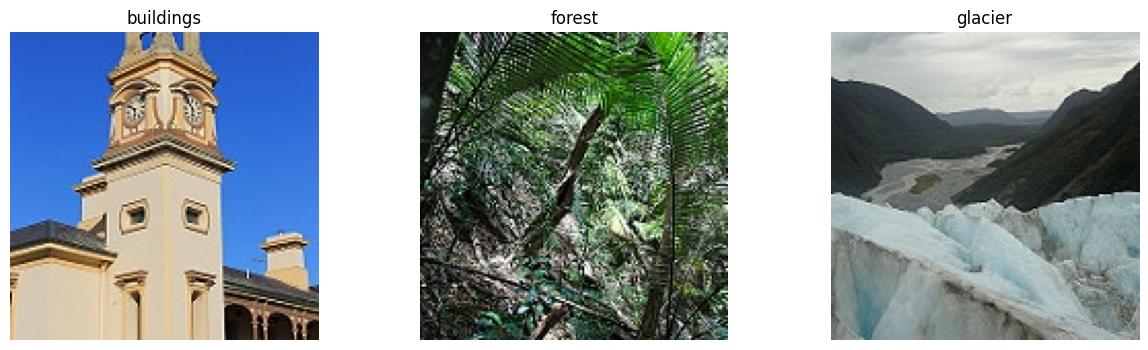

In [29]:
# Mostrar ejemplos por clase
fig, axes = plt.subplots(1, len(clases), figsize=(15, 4))
for ax, c in zip(axes, clases):
    ejemplo = os.listdir(os.path.join(train_dir, c))[0]
    img = Image.open(os.path.join(train_dir, c, ejemplo))
    ax.imshow(img)
    ax.set_title(c)
    ax.axis("off")
plt.show()

In [30]:
# Revisar tamaños de imagen (Intel NO siempre es 150x150 exacto)
tamaños = []
for c in clases:
    for f in os.listdir(os.path.join(train_dir, c))[:50]:
        img = Image.open(os.path.join(train_dir, c, f))
        tamaños.append(img.size)
print(set(tamaños))

{(150, 115), (150, 150)}


PREPARACION Y PROCESAMIENTO

In [31]:
IMG_SIZE = 64  # reducir resolución acelera mucho el entrenamiento de un MLP
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    classes=clases,       # si usan subconjunto, filtra solo esas carpetas
    seed=42
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    classes=clases,
    seed=42
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=clases,
    shuffle=False
)

Found 5494 images belonging to 3 classes.
Found 1372 images belonging to 3 classes.
Found 1464 images belonging to 3 classes.


DISEÑO DEL PERCEPTRON MULTICAPA

In [32]:
n_clases = len(clases)

# Flatter aplana la imagen a 64x64x3 = 12.288 valores, vector largo
modelo = Sequential([
    Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Dense(256, activation="relu"), # primera capa oculta, 256 neuronas
    Dropout(0.3),
    # Dropout no es una capa de neuronas,
    # apaga aleatoriamente el 30% de las conexiones durante el
    # entrenamiento (técnica para evitar el overfitting)
    Dense(128, activation="relu"), # segunda capa oculta, 128 neuronas
    Dense(n_clases, activation="softmax") # capa de salida
])

modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,267 (12.13 MB)

 Trainable params: 3,179,267 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

ENTRENAMIENTO

In [34]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = modelo.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.7572 - loss: 0.5783 - val_accuracy: 0.6283 - val_loss: 0.7444
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.7541 - loss: 0.5683 - val_accuracy: 0.7055 - val_loss: 0.6356
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.7552 - loss: 0.5616 - val_accuracy: 0.7478 - val_loss: 0.5978
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.7730 - loss: 0.5337 - val_accuracy: 0.6618 - val_loss: 0.7299
Epoch 5/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.7064 - loss: 0.6335 - val_accuracy: 0.7624 - val_loss: 0.5795
Epoch 6/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.7426 - loss: 0.5931 - val_accuracy: 0.7485 - val_loss: 0.5891
Epoch 7/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.7284 - loss: 0.6252 - val_accuracy: 0.7303 - val_loss: 0.6274
Epoch 8/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.7421 - loss: 0.6000 - 

In [11]:
modelo.save(f"{base}/models/modelo_mlp.keras")

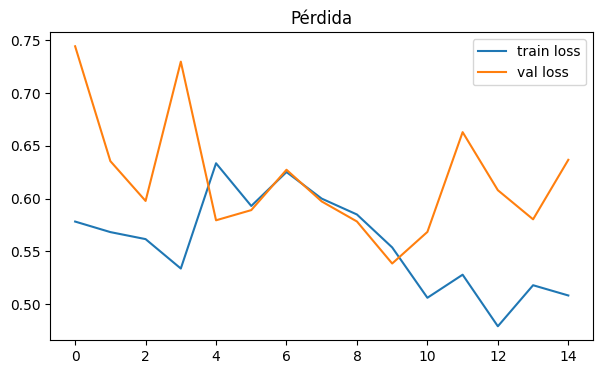

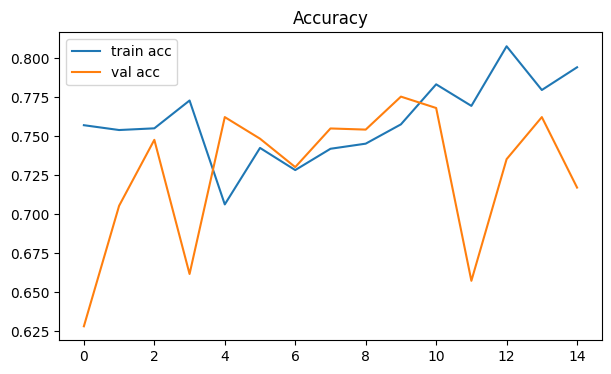

In [35]:
## Loss / Accuracy
hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(7,4))
plt.plot(hist_df["loss"], label="train loss")
plt.plot(hist_df["val_loss"], label="val loss")
plt.legend(); plt.title("Pérdida")
plt.savefig(f"{base}/images/curva_loss.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist_df["accuracy"], label="train acc")
plt.plot(hist_df["val_accuracy"], label="val acc")
plt.legend(); plt.title("Accuracy")
plt.savefig(f"{base}/images/curva_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

EVALUACION DEL DESEMPEÑO

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
Accuracy : 0.7704918032786885
Precision: 0.7749853515565457
Recall   : 0.7656616316060744
F1       : 0.7684352103339291


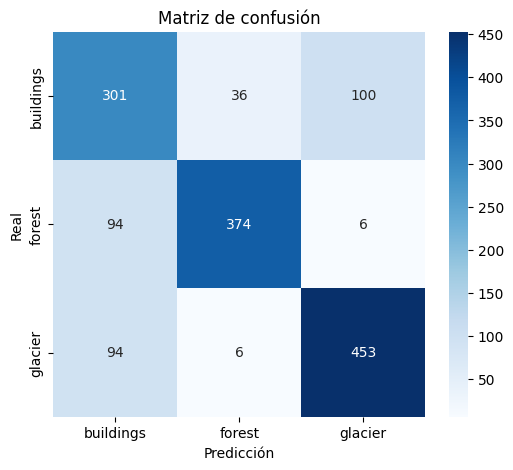

              precision    recall  f1-score   support

   buildings       0.62      0.69      0.65       437
      forest       0.90      0.79      0.84       474
     glacier       0.81      0.82      0.81       553

    accuracy                           0.77      1464
   macro avg       0.77      0.77      0.77      1464
weighted avg       0.78      0.77      0.77      1464



In [36]:
y_true = test_gen.classes
y_pred_probs = modelo.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro"))
print("Recall   :", recall_score(y_true, y_pred, average="macro"))
print("F1       :", f1_score(y_true, y_pred, average="macro"))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clases, yticklabels=clases, cmap="Blues")
plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title("Matriz de confusión")
plt.savefig(f"{base}/images/matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=clases))

ANALISIS DE ERRORES Y LIMTACIONES

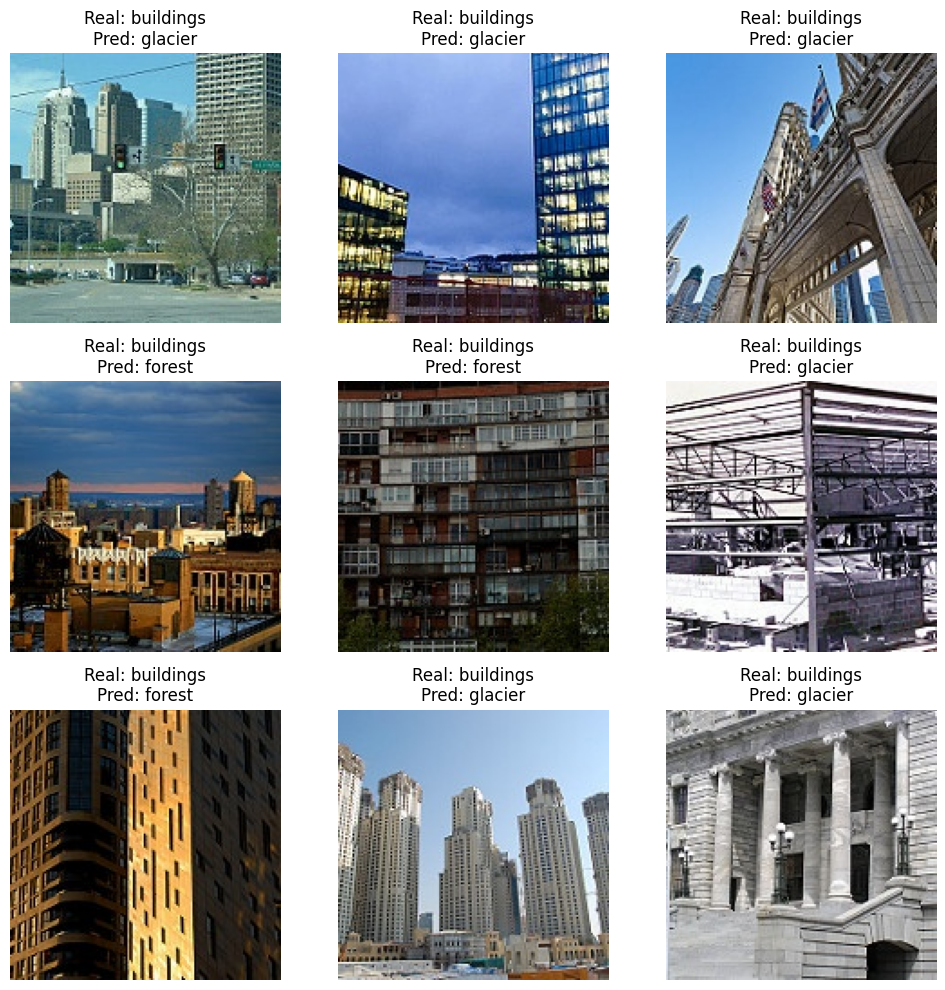

In [37]:
errores_idx = np.where(y_pred != y_true)[0][:9]
filenames = test_gen.filenames

fig, axes = plt.subplots(3, 3, figsize=(10,10))
for ax, idx in zip(axes.ravel(), errores_idx):
    img = plt.imread(os.path.join(test_dir, filenames[idx]))
    ax.imshow(img)
    ax.set_title(f"Real: {clases[y_true[idx]]}\nPred: {clases[y_pred[idx]]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{base}/images/errores_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()